In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [32]:
data = pd.read_csv('/Users/oguzhanerbil/Documents/Repolarım/food-health-predictor/data/data.csv')

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27600 entries, 0 to 27599
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      27599 non-null  float64
 1   miktar                      23464 non-null  float64
 2   markalar                    26824 non-null  object 
 3   alerjenler                  27600 non-null  object 
 4   eser_miktarlar              27600 non-null  object 
 5   icerik_sayisi               25234 non-null  float64
 6   nutriscore_notu             27553 non-null  object 
 7   nova_grubu                  24100 non-null  float64
 8   yesil_skor_notu             20511 non-null  object 
 9   palmiye_yagi_icermez        23552 non-null  object 
 10  vejetaryen                  22280 non-null  object 
 11  vegan_durumu                25335 non-null  object 
 12  enerji_kcal                 27316 non-null  float64
 13  yag_g                       273

In [34]:
data.describe()

,barkod,miktar,icerik_sayisi,nova_grubu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde
count,2.759900e+04,2.346400e+04,25234.000000,24100.000000,27316.000000,27314.000000,27071.000000,27286.000000,27197.000000,20028.000000,27314.000000,27401.000000,1371.000000,5915.000000
mean,4.367357e+12,4.261877e+07,12.854442,3.185062,276.077830,14.437263,4.858989,27.248437,10.347251,3.398003,7.663512,14.220541,4.951225,11.678727
std,2.506322e+12,6.528289e+09,12.583797,1.098997,407.491561,40.430268,9.072974,28.632228,19.718780,5.373676,10.822977,2150.443936,19.728981,30.346293
min,1.526000e+03,0.000000e+00,1.000000,1.000000,0.000000,-0.880969,-0.126229,0.000000,0.000000,0.000000,0.000000,-0.179539,0.000000,0.000000
25%,3.256220e+12,7.500000e+01,4.000000,3.000000,84.000000,1.100000,0.200000,4.200000,0.600000,0.500000,1.800000,0.040000,0.000000,0.000000
50%,3.770016e+12,2.000000e+02,10.000000,4.000000,241.000000,6.200000,1.500000,13.300000,3.400000,2.000000,6.100000,0.330000,0.000000,0.000000
75%,5.711953e+12,4.000000e+02,18.000000,4.000000,419.000000,21.000000,5.900000,53.000000,11.000000,4.800000,10.276786,1.000000,0.000000,4.062500
max,9.327007e+13,1.000001e+12,405.000000,4.000000,44600.000000,5856.650000,450.000000,955.000000,1070.422535,375.000000,800.000000,355942.500000,99.000000,449.400000


In [35]:
data.sample(5)

,barkod,miktar,markalar,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
22236,5.410041e+12,150.0,lu,"['Eggs', 'Gluten', 'Milk', 'Soybeans']",['Sesame seeds'],44.0,E,4.0,C,False,True,no,397.0,13.0,5.8,66.0,48.0,2.5,3.3,0.44,NaN,6.833482,g,"['Snacks', 'Sweet snacks', 'Biscuits and cakes...","['Distributor labels', 'No preservatives', 'Ch..."
1699,3.256224e+12,500.0,u,['Peanuts'],"['Milk', 'Nuts']",1.0,A,1.0,E,True,True,yes,625.0,51.0,8.0,8.5,4.8,8.0,29.0,0.01,NaN,0.000000,g,"['Plant-based foods and beverages', 'Plant-bas...",['Packaged in France']
21639,7.759220e+05,230.0,m&s food,"['Eggs', 'Milk']",[],11.0,D,3.0,NaN,True,True,no,383.0,39.4,9.0,4.9,2.2,0.1,2.2,0.55,NaN,NaN,g,"['Condiments', 'Sauces', 'Dips']",['FSC']
4905,3.256229e+12,140.0,u,[],[],1.0,A,1.0,C,True,True,yes,98.0,0.5,0.1,18.0,15.0,4.3,4.1,0.03,NaN,100.000000,g,"['Plant-based foods and beverages', 'Plant-bas...","['Organic', 'EU Organic', 'Nutriscore', 'Nutri..."
8590,8.586011e+12,NaN,kofola a.s.,[],[],19.0,B,4.0,NaN,False,True,yes,34.0,0.5,0.1,8.3,8.3,NaN,8.5,0.01,NaN,NaN,NaN,"['Beverages and beverages preparations', 'Beve...",[]


In [36]:
data.isnull().mean() * 100

barkod                         0.003623
miktar                        14.985507
markalar                       2.811594
alerjenler                     0.000000
eser_miktarlar                 0.000000
icerik_sayisi                  8.572464
nutriscore_notu                0.170290
nova_grubu                    12.681159
yesil_skor_notu               25.684783
palmiye_yagi_icermez          14.666667
vejetaryen                    19.275362
vegan_durumu                   8.206522
enerji_kcal                    1.028986
yag_g                          1.036232
doymus_yag_g                   1.916667
karbonhidrat_g                 1.137681
seker_g                        1.460145
lif_g                         27.434783
protein_g                      1.036232
tuz_g                          0.721014
alkol_yuzde                   95.032609
meyve_sebze_baklagil_yuzde    78.568841
birim                         16.931159
kategori_listesi               0.000000
etiketler_listesi              0.000000


In [37]:
for column in data.columns:
    unique_values = data[column].astype(str).unique()
    unique_values_str = sorted(list(unique_values))
    n = 10
    displayed_values = unique_values_str[:n]
    print(f"{column} ({len(unique_values_str)}): {displayed_values}{' ...' if len(unique_values_str) > n else ''}")

barkod (27600): ['10001219.0', '10001295.0', '10001400.0', '10001404.0', '10001707.0', '10001875.0', '10013108.0', '10015599.0', '1002553.0', '10037607.0'] ...
miktar (810): ['0.0', '0.045', '0.06', '0.07', '0.08', '0.085', '0.09', '0.095', '0.1', '0.104'] ...
markalar (6442): ['"tradition culinaire"', '07x netto 03.25', '1 2 3 fruits', '1 l', '100 plus', '1001 delights', '10dh', '166', '2025', '23 da'] ...
alerjenler (1087): ["['Acesulfame-potassium']", "['Apple', 'Banana', 'Gluten', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Nuts']", "['Apple', 'Banana', 'Gluten', 'Sulphur dioxide and sulphites']", "['Apple', 'Banana', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Milk']", "['Apple', 'Banana', 'Orange', 'Peach']", "['Apple', 'Celery', 'Gluten', 'Mustard', 'Soybeans']", "['Apple', 'Eggs', 'Gluten', 'Milk', 'Mustard', 'Sesame seeds']", "['Apple', 'Eggs', 'Gluten', 'Milk', 'Soybeans']"] ...
eser_miktarlar (1476): ["['2023-00986-16-9-fl-oz-mcct']", 

In [38]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['eser_miktarlar','kategori_listesi','alerjenler','etiketler_listesi',"markalar"]:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 50 ---")
    print(counts.head(50))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- eser_miktarlar - Top 50 ---
eser_miktarlar
Nuts                                                     4317
Soybeans                                                 3394
Milk                                                     2853
Gluten                                                   2162
Sesame seeds                                             1987
Eggs                                                     1951
Mustard                                                  1705
Peanuts                                                  1179
Celery                                                   1099
Fish                                                      609
Crustaceans                                               521
Molluscs                                                  459
Lupin                                                     353
Sulphur dioxide and sulphites                             225
Crustaceans-and-shellfish                                  18
Cereals-with-gluten    

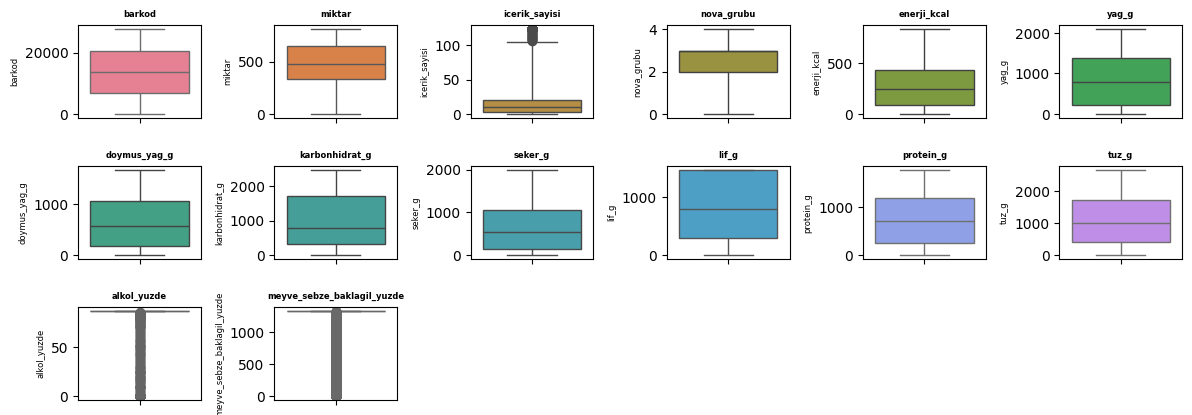

In [39]:
from sklearn.calibration import LabelEncoder
import seaborn as sns

veri = data.copy()

selected_columns = veri.select_dtypes(include=['number']).columns.tolist()

label_encoder = LabelEncoder()

for column in selected_columns:
    veri[column] = label_encoder.fit_transform(veri[column])

# Plot sayısını belirleyip subplotları ayarlayalım
fig, axes = plt.subplots(nrows=int(np.ceil(len(selected_columns)/3)), ncols=6, figsize=(12, 1 * int(np.ceil(len(selected_columns)/2))))

# Renk paleti seçimi
palette = sns.color_palette("husl", len(selected_columns))

# Boxplotları çizelim
axes = axes.flatten()
for i, col in enumerate(selected_columns):
    sns.boxplot(y=col, data=veri, ax=axes[i], color=palette[i], whis=5)
    axes[i].set_title(f'{col}', fontsize=6, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=6)

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grafik düzenini iyileştirelim
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=2.0)
plt.show()

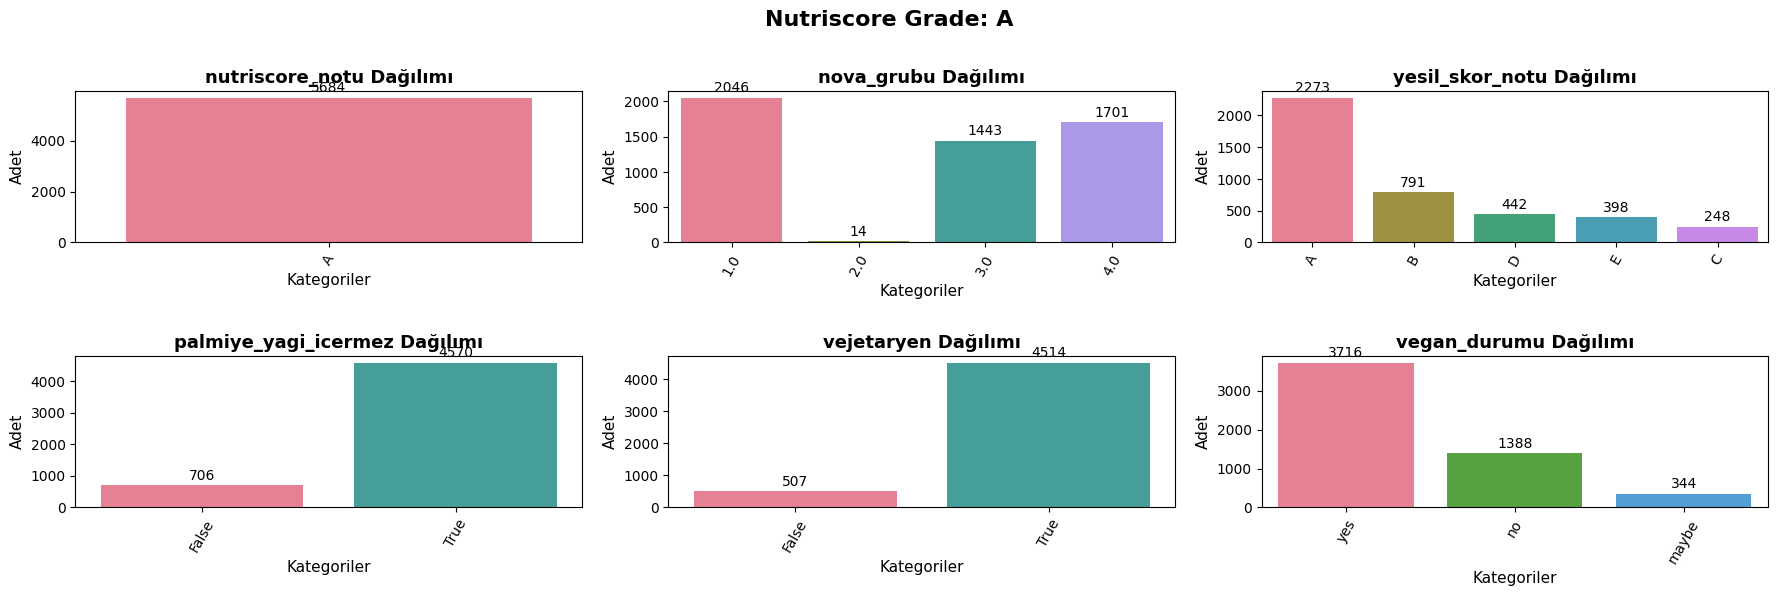

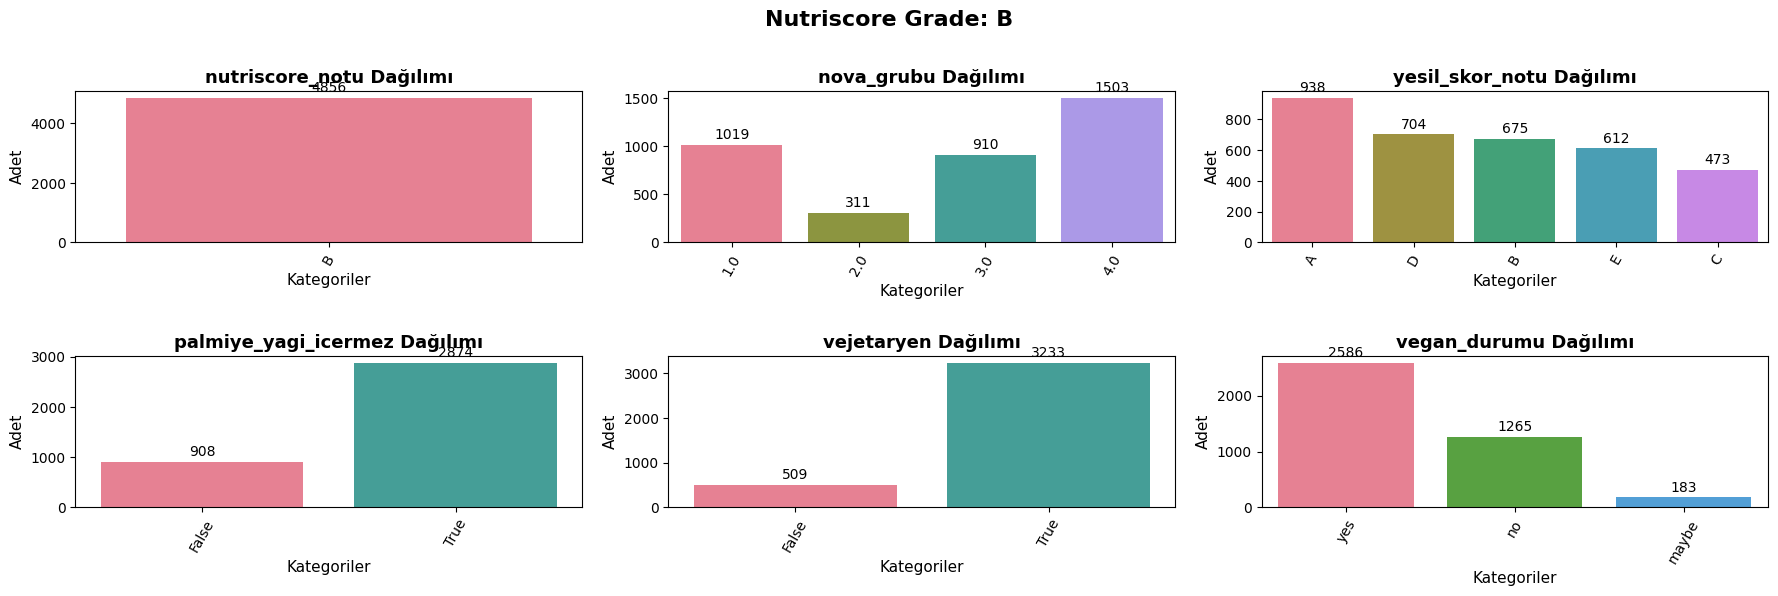

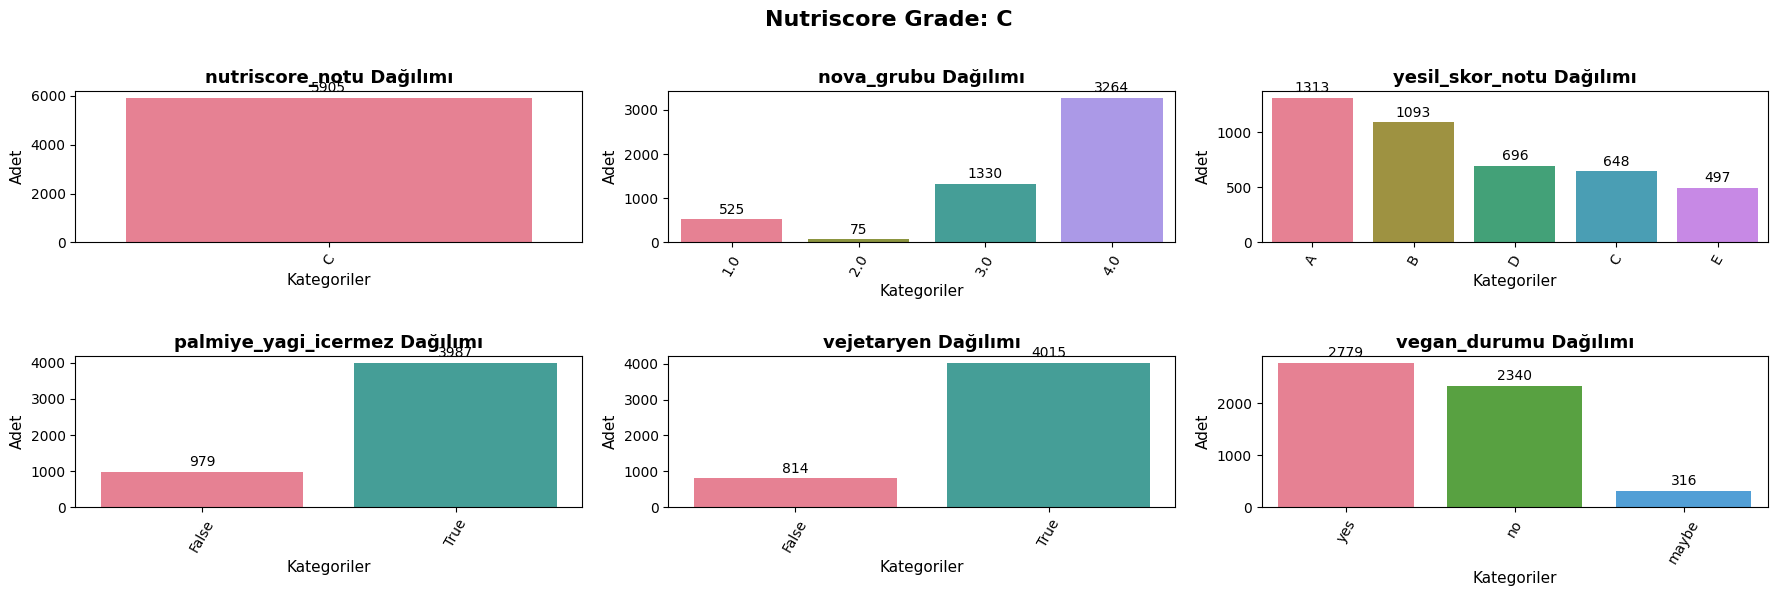

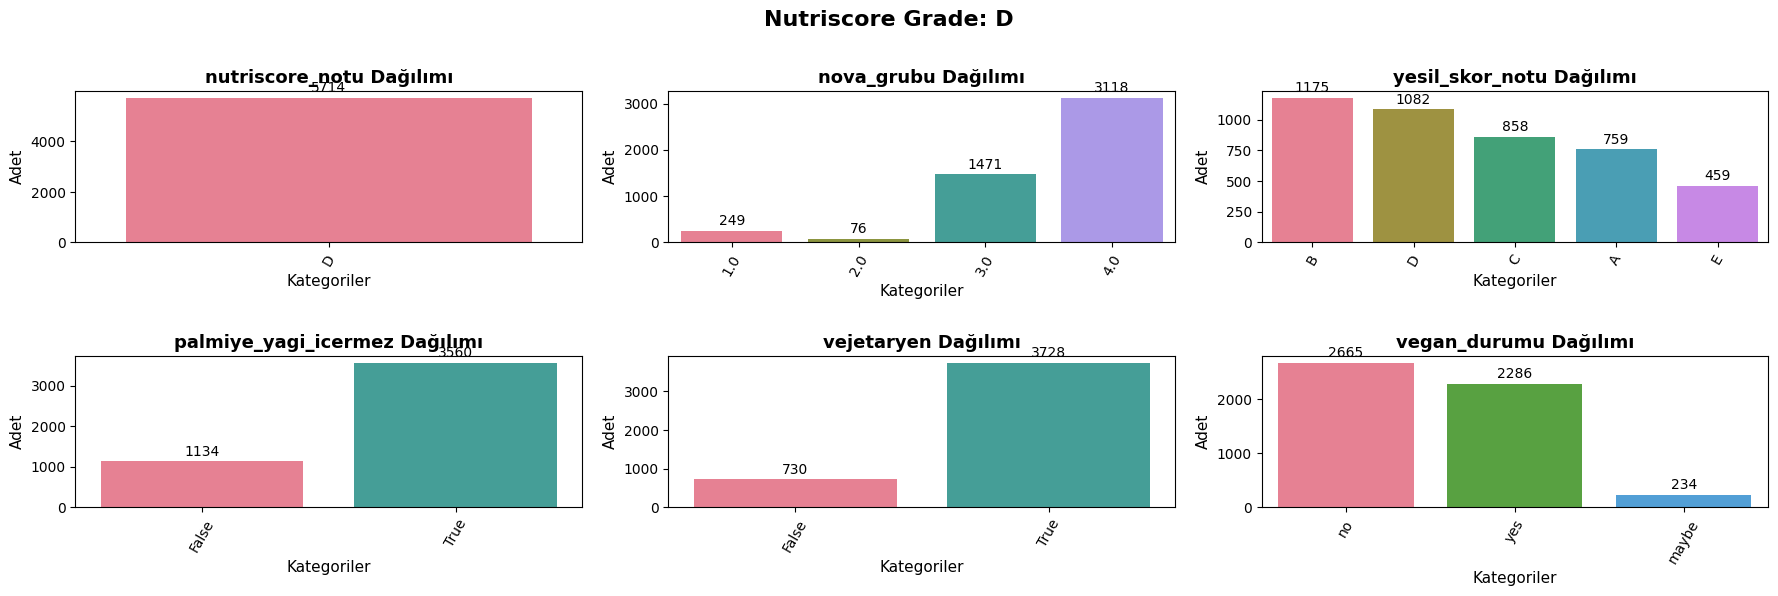

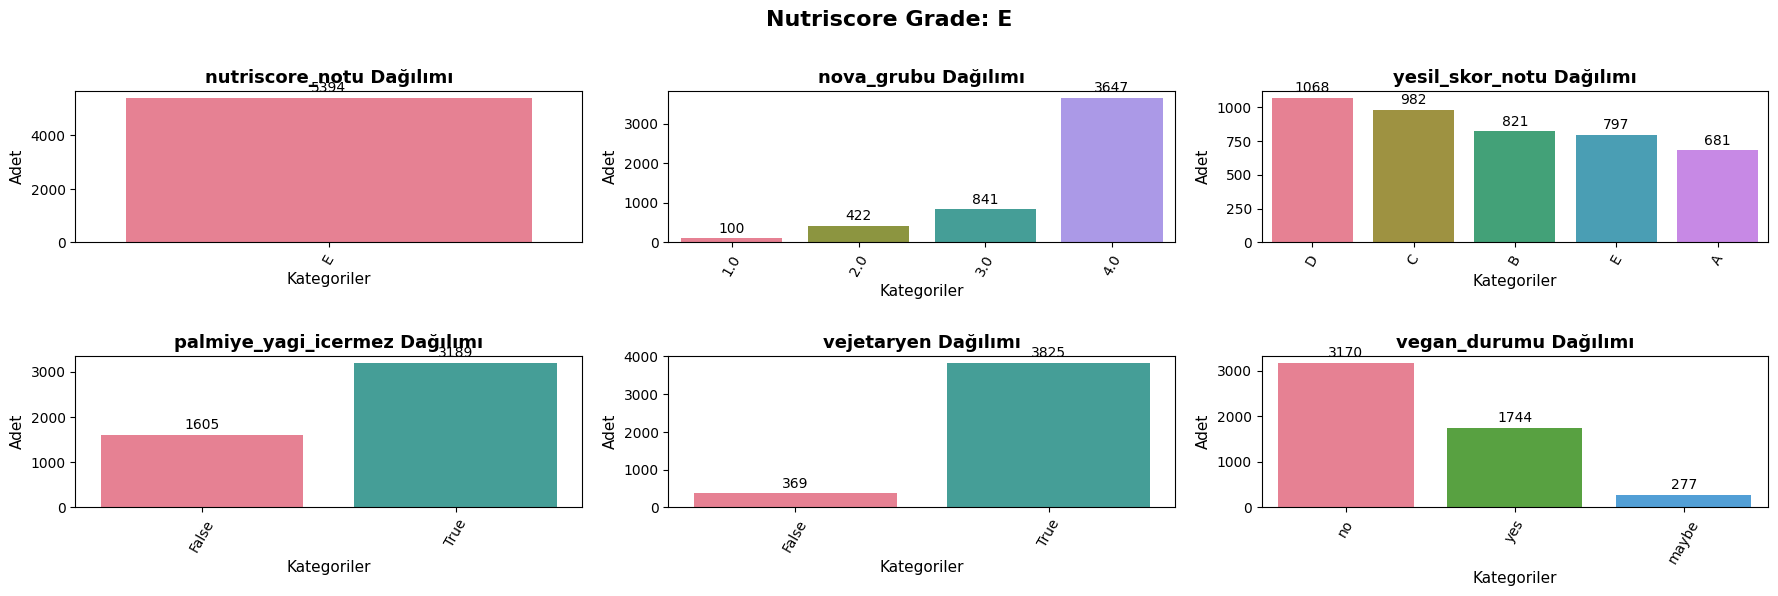

In [40]:
unique_counts = data.nunique()

categorical_columns = unique_counts[unique_counts <= 20].index.tolist()

# Nutriscore notlarına göre gruplandır
# exclude NaNs to avoid comparing floats and strings when sorting
nutriscore_grades = data['nutriscore_notu'].dropna().unique()
# sort safely by string representation
nutriscore_grades = sorted(nutriscore_grades, key=lambda x: str(x))

for grade in nutriscore_grades:
    grade_data = data[data['nutriscore_notu'] == grade]
    
    n_cols = 3
    n_rows = int(np.ceil(len(categorical_columns) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*3))
    axes = axes.flatten()
    
    fig.suptitle(f'Nutriscore Grade: {grade}', fontsize=16, fontweight='bold', y=0.995)
    
    for i, column in enumerate(categorical_columns):
        val_counts = grade_data[column].value_counts()
        sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='husl')
        axes[i].set_title(f'{column} Dağılımı', fontsize=13, fontweight='bold')
        axes[i].set_xlabel("Kategoriler", fontsize=11)
        axes[i].set_ylabel("Adet", fontsize=11)
        axes[i].tick_params(axis='x', rotation=60)
    
        # Her sütunun üzerine değerleri ekleyelim
        for p in axes[i].patches:
            axes[i].annotate(format(p.get_height(), '.0f'), 
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                             textcoords='offset points')
    
    # Kullanılmayan subplotları kaldıralım
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=2.5)
    plt.show()
